In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

# ==============================================================================
# 1. SETUP AND DATA LOADING
# ==============================================================================
# Intent: Initialize visualization environment and ingest processed datasets for analysis.

# --- Configuration ---
# Configure global plotting aesthetics for report-quality figures.
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.1)

# Custom Palette: Green for Win, Red for Loss
# Establish semantic color mapping for intuitive outcome distinction.
PALETTE = {"Win": "#2ecc71", "Loss": "#e74c3c"} 
# Enforce ordinal consistency for categorical feature visualization.
ORDER_FORM = ['Cold', 'Normal', 'Hot']
ORDER_RANK = ['Balanced', 'Moderate', 'Strong']

# --- Load Data ---
# Define relative paths to ensure cross-environment compatibility.
DATA_PATH = Path('../processed_data')
TRAIN_FILE = DATA_PATH / 'atp_matches_training.csv'
TEST_FILE = DATA_PATH / 'atp_matches_test_2024.csv'

try:
    # Ingest pre-processed training (historical) and test (future) datasets.
    df_train = pd.read_csv(TRAIN_FILE)
    df_test = pd.read_csv(TEST_FILE)
    
    # Output dataset dimensions to verify successful ingestion.
    print("--- Data Loaded Successfully ---")
    print(f"Training Set (2014-2023): {df_train.shape[0]} matches, {df_train.shape[1]} features")
    print(f"Test Set (2024):          {df_test.shape[0]} matches")
    
except FileNotFoundError:
    print("ERROR: Processed data not found. Run 'data_preparation.ipynb' first.")

--- Data Loaded Successfully ---
Training Set (2014-2023): 25648 matches, 13 features
Test Set (2024):          2932 matches


C:\Users\Francesco\AppData\Local\Temp\ipykernel_6312\3957880745.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train, x='Target_Win', palette=PALETTE, ax=axes[1])


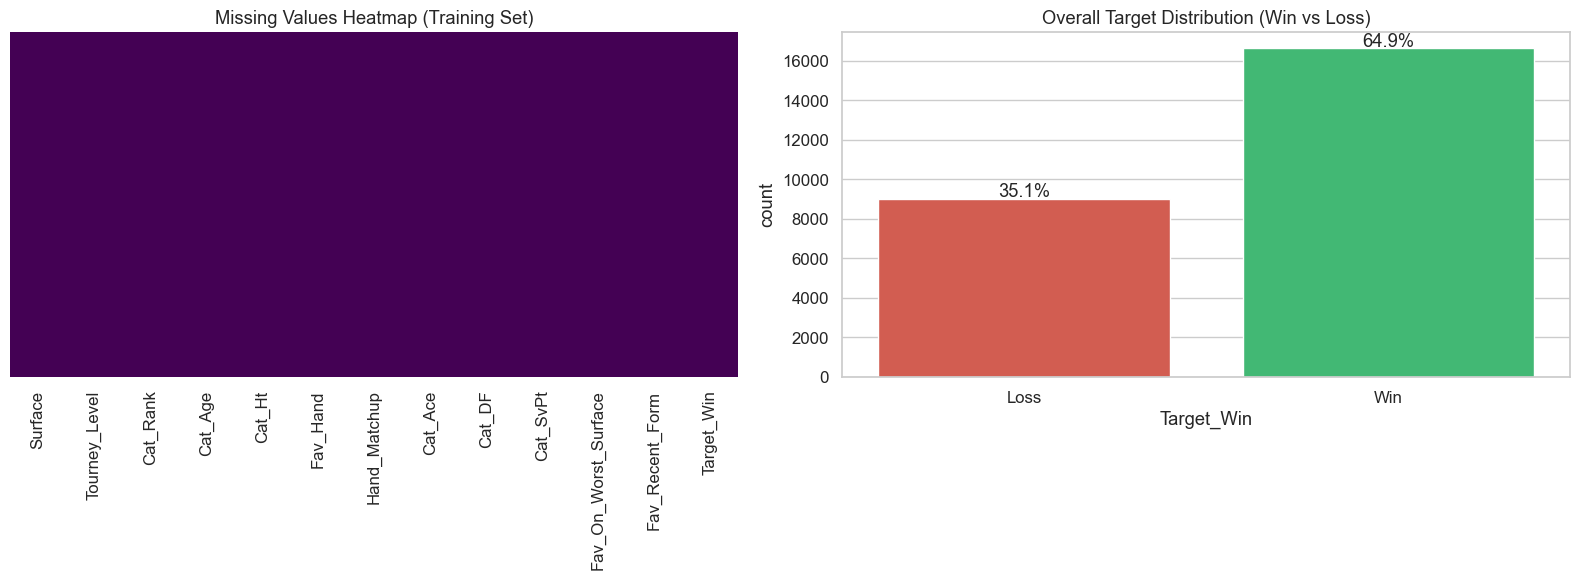


Check: Any remaining missing values? 
Series([], dtype: int64)


In [2]:
# ==============================================================================
# 2. DATA QUALITY AND TARGET DISTRIBUTION
# ==============================================================================
# Intent: Audit dataset integrity and establish class balance baseline.
# Logic: Visual inspection helps identify systematic missingness and determines the "Zero Rule" accuracy (predicting majority class).

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Missing Values Heatmap ---
# Visualize sparsity matrix.
# Logic: Continuous color blocks imply data health; vertical bands indicate feature-specific data loss.
sns.heatmap(df_train.isnull(), cbar=False, yticklabels=False, cmap='viridis', ax=axes[0])
axes[0].set_title("Missing Values Heatmap (Training Set)")

# --- Plot 2: Target Distribution (Baseline) ---
# Quantify class imbalance.
# Logic: Essential to interpret accuracy metrics later. If Favorites win 70% of the time, 70% accuracy is merely baseline.
sns.countplot(data=df_train, x='Target_Win', palette=PALETTE, ax=axes[1])
axes[1].set_title("Overall Target Distribution (Win vs Loss)")

# Add percentages
# Annotate relative frequencies.
total = len(df_train)
for p in axes[1].patches:
    height = p.get_height()
    axes[1].text(p.get_x() + p.get_width() / 2., height + 100,
                 f'{height/total:.1%}', ha="center")

plt.tight_layout()
plt.show()

# Final validation: Report any persistent nulls preventing model training.
print(f"\nCheck: Any remaining missing values? \n{df_train.isnull().sum()[df_train.isnull().sum()>0]}")

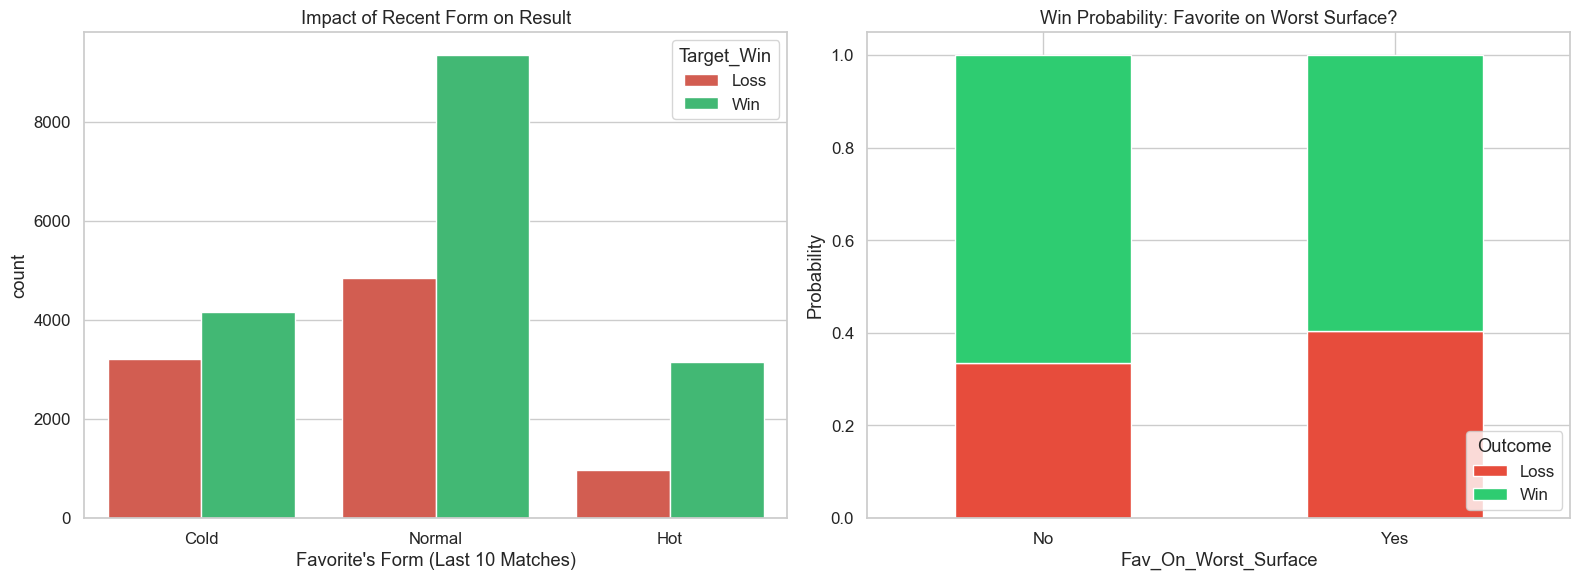


--- Win Rates by Form ---
Fav_Recent_Form
Cold      0.564012
Hot       0.765537
Normal    0.658913
Name: Win, dtype: float64


In [3]:
# ==============================================================================
# 3. ANALYSIS: FORM & SURFACE
# ==============================================================================
# Intent: Evaluate predictive power of domain-specific features.
# Logic: Visual validation of hypothesis that momentum (Form) and environmental context (Surface) influence outcomes.

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Impact of Recent Form ---
# Assess momentum impact.
# Logic: Correlate categorical form tiers (Hot/Cold) with absolute win counts to verify momentum theory.
sns.countplot(
    data=df_train, 
    x='Fav_Recent_Form', 
    hue='Target_Win', 
    order=ORDER_FORM, 
    palette=PALETTE, 
    ax=axes[0]
)
axes[0].set_title("Impact of Recent Form on Result")
axes[0].set_xlabel("Favorite's Form (Last 10 Matches)")

# --- Plot 2: Impact of Worst Surface (Probability) ---
# Quantify surface disadvantage.
# Logic: Use normalized probabilities (stacked bar) instead of raw counts to handle class imbalance 
#        (Matches on "Worst Surface" are significantly rarer than standard matches).
props_surf = df_train.groupby("Fav_On_Worst_Surface")['Target_Win'].value_counts(normalize=True).unstack()
props_surf.plot(kind='bar', stacked='True', color=[PALETTE['Loss'], PALETTE['Win']], ax=axes[1])

axes[1].set_title("Win Probability: Favorite on Worst Surface?")
axes[1].set_ylabel("Probability")
axes[1].legend(title='Outcome', loc='lower right')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Print numerical insights
# Extract exact win-rates to validate visual trends.
print("\n--- Win Rates by Form ---")
print(df_train.groupby('Fav_Recent_Form')['Target_Win'].value_counts(normalize=True).unstack()['Win'])

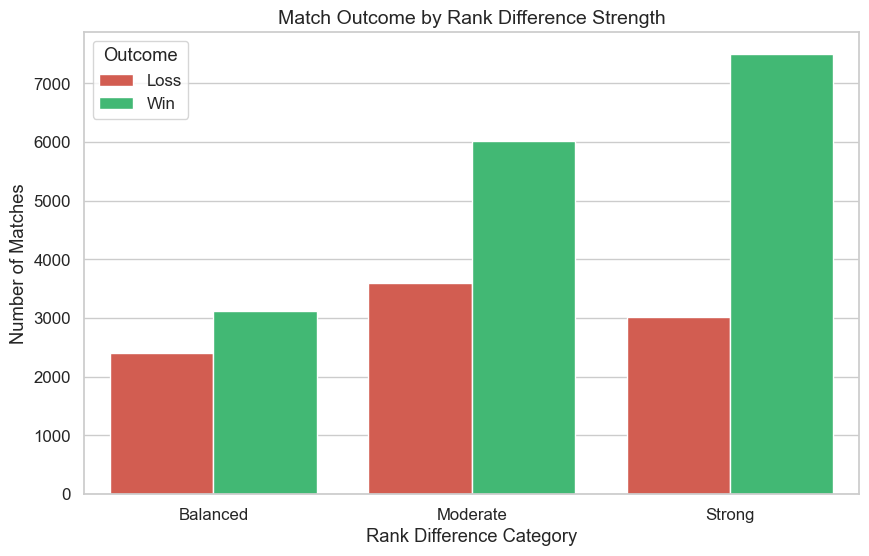

In [ ]:
# ==============================================================================
# 4. RANKING ANALYSIS
# ==============================================================================
# Intent: Visualize correlation between ranking disparity and match outcome.
# Logic: Validate hypothesis that 'Strong' rank differences favor the higher-ranked player significantly.

plt.figure(figsize=(10, 6))

# Construct frequency plot categorized by rank gap magnitude.
# Logic: Contrast Win/Loss counts across 'Balanced', 'Moderate', and 'Strong' tiers to estimate predictive power of Ranking.
ax = sns.countplot(
    data=df_train, 
    x='Cat_Rank', 
    hue='Target_Win', 
    order=ORDER_RANK,
    palette=PALETTE
)

# Apply standardization labels.
plt.title("Match Outcome by Rank Difference Strength", fontsize=14)
plt.xlabel("Rank Difference Category")
plt.ylabel("Number of Matches")

plt.legend(title='Outcome')
plt.show()

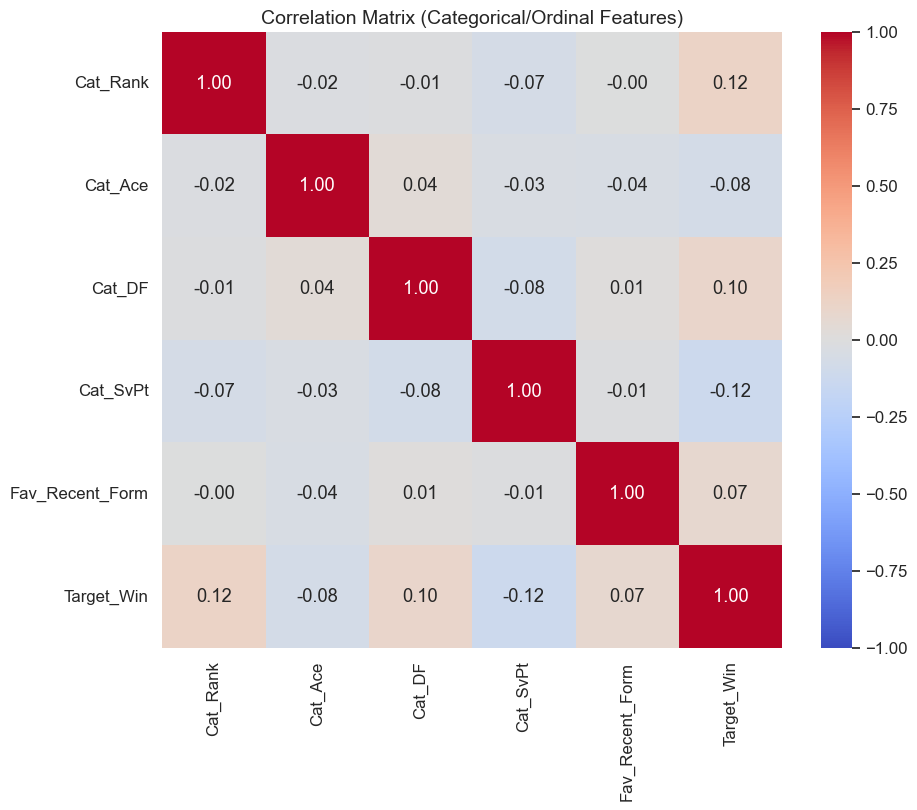

In [5]:
# ==============================================================================
# 5. CORRELATION MATRIX (Numerical Features)
# ==============================================================================
# Intent: Assess feature interdependence and predictive strength.
# Logic: Pearson correlation requires numerical input; ordinal encoding is applied as a proxy for discretized features.

# Create isolation copy to preserve training data integrity.
df_corr = df_train.copy()
# Serialize target variable (Win=1) for correlation computation.
df_corr['Target_Numeric'] = df_corr['Target_Win'].map({'Win': 1, 'Loss': 0})

# --- Ordinal Encoding ---
# Select subset of features with inherent order.
cols_to_encode = ['Cat_Rank', 'Cat_Ace', 'Cat_DF', 'Cat_SvPt', 'Fav_Recent_Form', 'Target_Win']

# Transform ordinal categories (e.g., 'Low', 'Medium', 'High') into integer representations.
# Logic: Enables mathematical correlation analysis on discretized datasets.
for col in cols_to_encode:
    if col in df_corr.columns:
        df_corr[col] = df_corr[col].astype('category').cat.codes

# --- Visualization ---
# Generate heatmap to identify multicollinearity and feature-target relationships.
plt.figure(figsize=(10, 8))
sns.heatmap(df_corr[cols_to_encode].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix (Categorical/Ordinal Features)", fontsize=14)
plt.show()

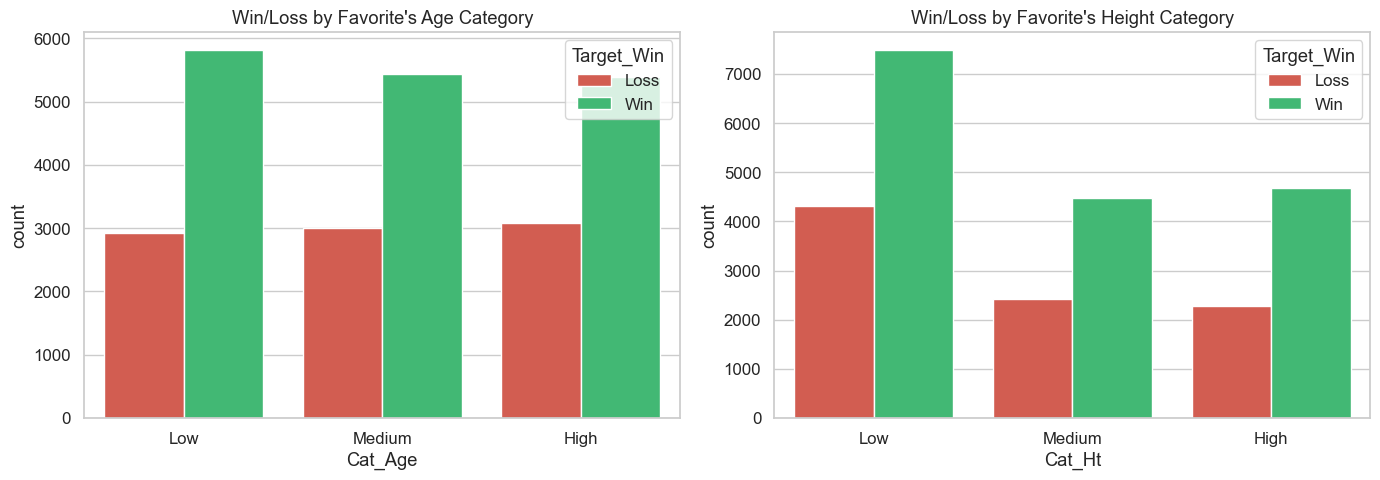

In [6]:
# ==============================================================================
# 6. PHYSICAL STATS DISTRIBUTION
# ==============================================================================
# Intent: Explore relationship between physical attributes (Age/Height) and match success.
# Logic: Uses discretized buckets (Low/Medium/High) to smooth noise and identify broad trends.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Note: Since we discretized Age and Height in the previous step, 
# we visualize the Categories here.

# Age Category
# Contrast win/loss frequency across age groups.
# Logic: Detect if "Prime" age (Medium) or "Experience" (High) confers statistical advantage.
sns.countplot(data=df_train, x='Cat_Age', hue='Target_Win', palette=PALETTE, ax=axes[0], order=['Low', 'Medium', 'High'])
axes[0].set_title("Win/Loss by Favorite's Age Category")

# Height Category
# Evaluate advantage of physical stature.
# Logic: Taller players (High) typically possess stronger serves; this plot validates that heuristic.
sns.countplot(data=df_train, x='Cat_Ht', hue='Target_Win', palette=PALETTE, ax=axes[1], order=['Low', 'Medium', 'High'])
axes[1].set_title("Win/Loss by Favorite's Height Category")

plt.tight_layout()
plt.show()

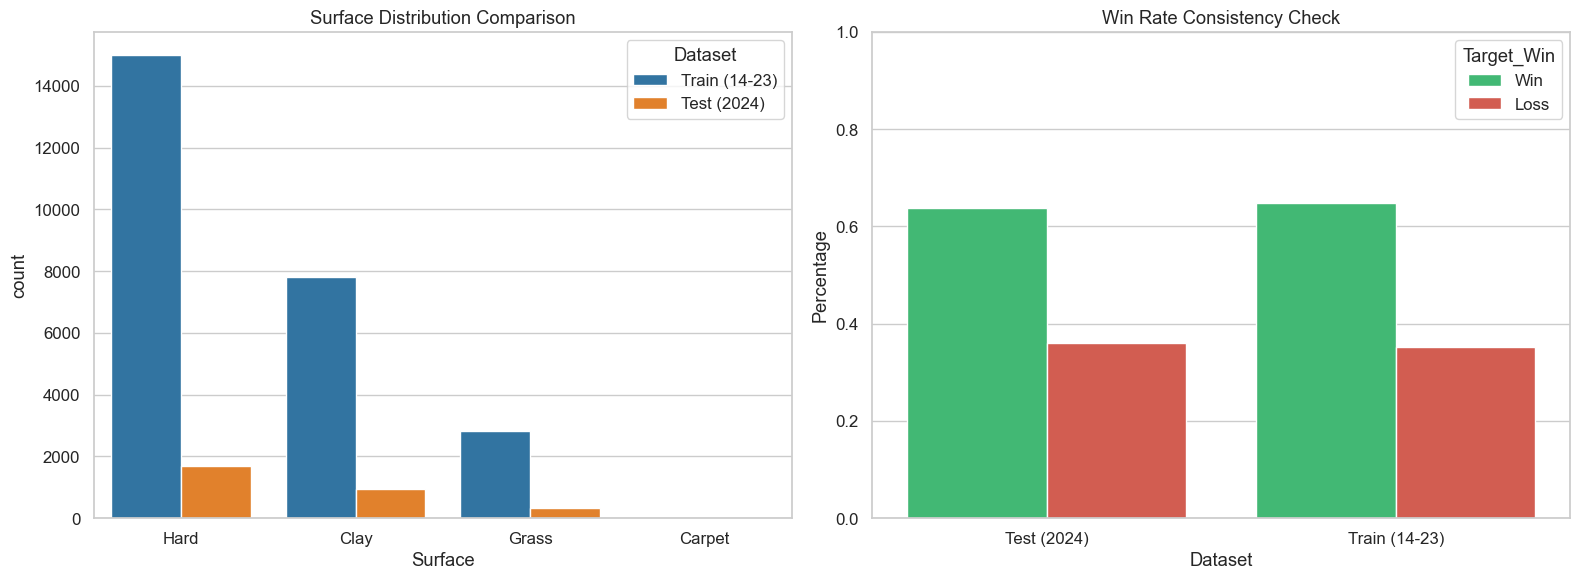

Insight: If the bars in Plot 2 are similar height, the 2024 season is consistent with history.


In [7]:
# ==============================================================================
# 7. DATA DRIFT CHECK: TRAIN (2014-2023) vs TEST (2024)
# ==============================================================================
# Intent: Detect temporal distribution shift (Covariate Shift & Concept Drift).
# Logic: Ensure training assumptions (historical patterns) remain valid for the 2024 testing period.

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Surface Distribution Comparison ---
# Aggregate datasets to visualize covariate shift in environmental features.
data_comparison = pd.concat([
    df_train[['Surface']].assign(Dataset='Train (14-23)'),
    df_test[['Surface']].assign(Dataset='Test (2024)')
])

sns.countplot(data=data_comparison, x='Surface', hue='Dataset', ax=axes[0])
axes[0].set_title("Surface Distribution Comparison")

# --- Plot 2: Win Rate Comparison ---
# Quantify concept drift in target variable.
target_comparison = pd.concat([
    df_train[['Target_Win']].assign(Dataset='Train (14-23)'),
    df_test[['Target_Win']].assign(Dataset='Test (2024)')
])

# Normalize class frequencies.
# Logic: Essential to correct for sample size disparity between longitudinal training data (10 years) and single-year test set.
props_target = target_comparison.groupby(['Dataset'])['Target_Win'].value_counts(normalize=True).rename('Percentage').reset_index()

sns.barplot(data=props_target, x='Dataset', y='Percentage', hue='Target_Win', palette=PALETTE, ax=axes[1])
axes[1].set_title("Win Rate Consistency Check")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

print("Insight: If the bars in Plot 2 are similar height, the 2024 season is consistent with history.")